# OFTEC-NN Training and Synthesis Notebook

## Table of Contents
- [1 Training a Neural Network](#1-Training-a-Neural-Network)
- [2. Network Preparation](#2.-Network-Preparation)
- [3. Building the Network](#3.-Building-the-Network)

## 1. Training a Neural Network

### 1.1.  Loading datasets

First of all, we need to load images from left and right scenes and their corresponding groundtruth.

#### 1.1.1 Load right images

In [10]:
import re
import imageio
import os
from skimage.color import rgb2gray
from skimage.transform import resize  # Import the resize function from skimage.transform
import numpy as np

s1=512
s2=512

# Specify the desired image size
desired_size = (s1, s2)  # Replace with your desired size

# Specify the file path of the .tif images folder
folder_path = "F:/lesson_3/project/sample/OrigImages0tm325/Right"  # Replace with the actual folder path

# List all files in the folder
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path)]

# Natural sort the file paths based on the numeric part of the file name
file_paths.sort(key=lambda x: [int(part) if part.isdigit() else part for part in re.split('(\d+)', os.path.splitext(os.path.basename(x))[0])])

# Load, resize, convert to grayscale, and normalize each image
imagesR = []
for file_path in file_paths:
    # Load the image
    image = imageio.imread(file_path)

    # Resize the image to the desired size
    resized_image = resize(image, desired_size, anti_aliasing=True)  # Use the resize function to resize the image

    # Convert the resized image to grayscale
    grayscale_image = rgb2gray(resized_image)

    # Normalize the grayscale image between 0 and 1
    normalized_image = (grayscale_image - grayscale_image.min()) / (grayscale_image.max() - grayscale_image.min())

    # Append the normalized image to the list
    imagesR.append(normalized_image)


C:\Users\asus\AppData\Local\Temp\ipykernel_10464\1188340384.py:27: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(file_path)


#### 1.1.2.Load left images

In [11]:
import imageio as imageio
import os
import re
from skimage.color import rgb2gray
from skimage.transform import resize
import numpy as np

# Specify the desired image size
#desired_size = (s1, s2)  # Replace with your desired size

# Specify the file path of the .tif images folder
folder_path = "F:/lesson_3/project/sample/OrigImages0tm325/Left"  # Replace with the actual folder path

# List all files in the folder
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path)]

# Natural sort the file paths based on the numeric part of the file name
file_paths.sort(key=lambda x: [int(part) if part.isdigit() else part for part in re.split('(\d+)', os.path.splitext(os.path.basename(x))[0])])

# Load, resize, convert to grayscale, and normalize each image
imagesL = []
for file_path in file_paths:
    # Load the image
    image = imageio.imread(file_path)

    # Resize the image to the desired size
    resized_image = resize(image, desired_size, anti_aliasing=True)

    # Convert the resized image to grayscale
    grayscale_image = rgb2gray(resized_image)

    # Normalize the grayscale image between 0 and 1
    normalized_image = (grayscale_image - grayscale_image.min()) / (grayscale_image.max() - grayscale_image.min())

    # Append the normalized image to the list
    imagesL.append(normalized_image)

C:\Users\asus\AppData\Local\Temp\ipykernel_10464\720474874.py:24: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imageio.imread(file_path)


#### 1.1.3.Load groundtruths

In [12]:
import numpy as np
from skimage.transform import resize  # Import the resize function from skimage.transform

# Specify the desired image size
#desired_size = (s1,s2)  # Replace with your desired size

# Specify the file path of the .txt files folder
folder_path = "F:/lesson_3/project/sample/GroundTruth/Disparity/normgtTXT"  # Replace with the actual folder path

# List all files in the folder
file_paths = [os.path.join(folder_path, file) for file in os.listdir(folder_path)]

# Natural sort the file paths based on the numeric part of the file name
file_paths.sort(key=lambda x: [int(part) if part.isdigit() else part for part in re.split('(\d+)', os.path.splitext(os.path.basename(x))[0])])

# Load and normalize each .txt file
data = []
for file_path in file_paths:
    # Load the .txt file
    #print(file_path)
    image = np.loadtxt(file_path)
    

    # Resize the image to the desired size
    raw_data = resize(image, desired_size, anti_aliasing=True)  # Use the resize function to resize the image

    # Normalize the data between 0 and 1
    normalized_data = (raw_data - raw_data.min()) / (raw_data.max() - raw_data.min())

    # Append the normalized data to the list
    data.append(normalized_data)

#### 1.1.4. Visualising some sample of datasets

Here, we can visualise left,right or groundtruth images.

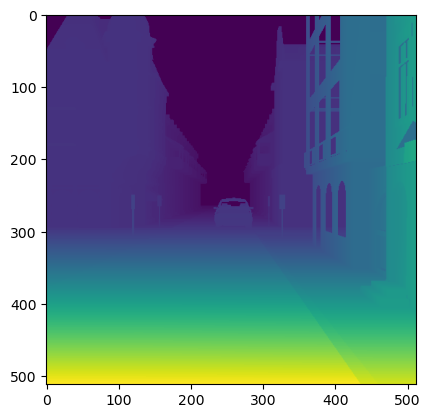

In [13]:
first_file_data = data[200]
import matplotlib.pyplot as plt
plt.imshow(first_file_data , cmap='viridis')

### 1.2. Load datasets into dataloaders

In [14]:
m1 = 0
n1 = 199
m2 = 324
n2 = 325

# Concatenate the first part of images along axis=0
concatenated_dataR_part1 = np.concatenate(imagesR[m1:n1], axis=0)

# Concatenate the second part of images along axis=0
concatenated_dataR_part2 = np.concatenate(imagesR[m2:n2], axis=0)

# Concatenate the images along axis=0 for the first part
concatenated_dataR = np.concatenate([concatenated_dataR_part1, concatenated_dataR_part2], axis=0)

# Display the shape of the concatenated data
print("Shape of concatenated dataR:", concatenated_dataR.shape)

# Repeat the same process for imagesL and data
concatenated_dataL_part1 = np.concatenate(imagesL[m1:n1], axis=0)
concatenated_dataL_part2 = np.concatenate(imagesL[m2:n2], axis=0)
concatenated_dataL = np.concatenate([concatenated_dataL_part1, concatenated_dataL_part2], axis=0)
print("Shape of concatenated dataL:", concatenated_dataL.shape)

concatenated_gt_part1 = np.concatenate(data[m1:n1], axis=0)
concatenated_gt_part2 = np.concatenate(data[m2:n2], axis=0)
concatenated_gt = np.concatenate([concatenated_gt_part1, concatenated_gt_part2], axis=0)
print("Shape of concatenated data:", concatenated_gt.shape)

Shape of concatenated dataR: (102400, 512)
Shape of concatenated dataL: (102400, 512)
Shape of concatenated data: (102400, 512)


In [15]:
m=0
n=200
# Concatenate the images along axis=0
concatenated_dataR = np.concatenate(imagesR[m:n], axis=0)

# Display the shape of the concatenated data
print("Shape of concatenated dataR:", concatenated_dataR.shape)

# Concatenate the images along axis=0
concatenated_dataL = np.concatenate(imagesL[m:n], axis=0)

# Display the shape of the concatenated data
print("Shape of concatenated dataL:", concatenated_dataL.shape)

# Concatenate the images along axis=0
concatenated_gt = np.concatenate(data[m:n], axis=0)

# Display the shape of the concatenated data
print("Shape of concatenated data:", concatenated_gt.shape)

import torch
# Convert the data to PyTorch tensors
concatenated_dataL_tensor = torch.tensor(concatenated_dataL, dtype=torch.float32)
concatenated_dataR_tensor = torch.tensor(concatenated_dataR, dtype=torch.float32)
concatenated_gt_tensor = torch.tensor(concatenated_gt, dtype=torch.float32)


import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, left_matrix, right_matrix, ground_truth):
        self.left_matrix = left_matrix
        self.right_matrix = right_matrix
        self.ground_truth = ground_truth

    def __len__(self):
        return self.left_matrix.shape[0]

    def __getitem__(self, index):
        left_input = self.left_matrix[index]
        right_input = self.right_matrix[index]
        target = self.ground_truth[index]

        # Reshape the input matrices to match the expected shape of the model
        left_input = left_input.unsqueeze(dim=0)  # Add a channel dimension
        right_input = right_input.unsqueeze(dim=0)  # Add a channel dimension
        target = target.unsqueeze(dim=0)  # Add a channel dimension

        return left_input, right_input, target

from sklearn.model_selection import train_test_split

left, leftV, right, rightV, gt, gtV = train_test_split(concatenated_dataL_tensor,
                                                       concatenated_dataR_tensor,
                                                       concatenated_gt_tensor, test_size=0.15)

# Create PyTorch Datasets for training and validation
train_dataset = MyDataset(left, right, gt)
val_dataset = MyDataset(leftV, rightV, gtV)

# Create PyTorch DataLoaders for training and validation
batch_size = 128
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=True)


Shape of concatenated dataR: (102400, 512)
Shape of concatenated dataL: (102400, 512)
Shape of concatenated data: (102400, 512)


### 1.3.Training Pytorch model

In [16]:

import torch
import torch.nn as nn

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Replace "0" with the index of the GPU you want to use

l1 = 64
l2 = 64
l3 = 64

input_size = s2

# Define the model
class StereoModel(nn.Module):
    def __init__(self):
        super(StereoModel, self).__init__()

        self.path1_combined = nn.Sequential(
            nn.Conv1d(1, l1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(l1, l2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(l2, l3, kernel_size=3, padding=1),
            nn.ReLU()
        )

        self.path2_combined = nn.Sequential(
            nn.Conv1d(1, l1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(l1, l2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(l2, l3, kernel_size=3, padding=1),
            nn.ReLU()
        )

        # Combine paths
        self.combined = nn.Sequential(
            nn.Conv1d(2 * l3, l3, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(l3, l2, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2),  # Upsample to match input size
            nn.Conv1d(l2, l1, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2)  # Upsample to match input size
        )

        self.output = nn.Conv1d(l1, 1, kernel_size=3, padding=1)

    def forward(self, left_input, right_input):
        path1_combined_out = self.path1_combined(left_input)
        path2_combined_out = self.path2_combined(right_input)

        combined = torch.cat((path1_combined_out, path2_combined_out), dim=1)
        combined_out = self.combined(combined)
        output = self.output(combined_out)

        return output

# Create an instance of the model
model = StereoModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use CUDA if available
model.to(device)
print(model)  # Print the model summary

StereoModel(
  (path1_combined): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
  )
  (path2_combined): Sequential(
    (0): Conv1d(1, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
  )
  (combined): Sequential(
    (0): Conv1d(128, 64, kernel_size=(3,), st

In [17]:
import torch
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"Device Count: {torch.cuda.device_count()}")
else:
    print("PyTorch cannot see a GPU. Ensure your drivers and torch-cuda are installed.")


CUDA Available: True
GPU Device: NVIDIA GeForce GTX 1650
Device Count: 1


In [18]:
#import os
#os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Replace "0" with the index of the GPU you want to use

import torch
import torch.nn as nn
import torch.optim as optim

# Define the model
model = StereoModel()

# Define the loss function
criterion = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adjust the learning rate as needed

# Training loop
epochs = 30 # Number of training epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use CUDA if available

model.to(device)  # Move the model to the device (GPU or CPU)

# Lists to store training and validation loss values
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = 0.0

    # Training
    model.train()  # Set the model to training mode
    for left, right, disparity in train_dataloader:

        # Move the tensors to the device
        left = left.to(device)
        right = right.to(device)
        disparity = disparity.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(left, right)

        # Compute the loss
        loss = criterion(output, disparity)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # Accumulate the training loss
        train_loss += loss.item() * left.size(0)

    # Calculate the average training loss for the epoch
    train_loss /= len(train_dataloader.dataset)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0

    with torch.no_grad():
        for left, right, disparity in val_dataloader:

            # Move the tensors to the device
            left = left.to(device)
            right = right.to(device)
            disparity = disparity.to(device)

            # Forward pass
            output = model(left, right)

            # Compute the loss
            loss = criterion(output, disparity)

            # Accumulate the validation loss
            val_loss += loss.item() * left.size(0)

    # Calculate the average validation loss for the epoch
    val_loss /= len(val_dataloader.dataset)
    val_loss_history.append(val_loss)

    # Print the losses for each epoch
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


Epoch 1/30 - Train Loss: 0.0402 - Val Loss: 0.0215
Epoch 2/30 - Train Loss: 0.0186 - Val Loss: 0.0149
Epoch 3/30 - Train Loss: 0.0135 - Val Loss: 0.0135
Epoch 4/30 - Train Loss: 0.0113 - Val Loss: 0.0108
Epoch 5/30 - Train Loss: 0.0098 - Val Loss: 0.0086
Epoch 6/30 - Train Loss: 0.0089 - Val Loss: 0.0090
Epoch 7/30 - Train Loss: 0.0081 - Val Loss: 0.0076
Epoch 8/30 - Train Loss: 0.0074 - Val Loss: 0.0070
Epoch 9/30 - Train Loss: 0.0074 - Val Loss: 0.0065
Epoch 10/30 - Train Loss: 0.0066 - Val Loss: 0.0066
Epoch 11/30 - Train Loss: 0.0065 - Val Loss: 0.0058
Epoch 12/30 - Train Loss: 0.0061 - Val Loss: 0.0060
Epoch 13/30 - Train Loss: 0.0061 - Val Loss: 0.0053
Epoch 14/30 - Train Loss: 0.0056 - Val Loss: 0.0052
Epoch 15/30 - Train Loss: 0.0053 - Val Loss: 0.0076
Epoch 16/30 - Train Loss: 0.0056 - Val Loss: 0.0052
Epoch 17/30 - Train Loss: 0.0051 - Val Loss: 0.0049
Epoch 18/30 - Train Loss: 0.0049 - Val Loss: 0.0046
Epoch 19/30 - Train Loss: 0.0054 - Val Loss: 0.0047
Epoch 20/30 - Train L

In [19]:
torch.save(model.state_dict(), 'new_model_scripted.pt')

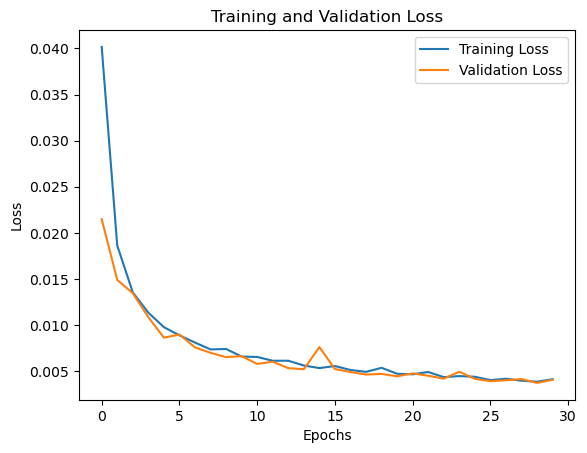

In [20]:
import matplotlib.pyplot as plt

epochs = range(0, len(train_loss_history) )
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
#plt.show()

plt.legend()
plt.savefig('output.png', dpi=1000, format='png', bbox_inches='tight', pad_inches=0.2)


Average error: 0.18944734240335132
Average inference time: 0.0020817688533238004 seconds


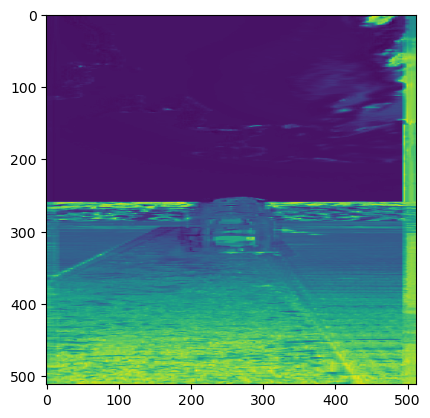

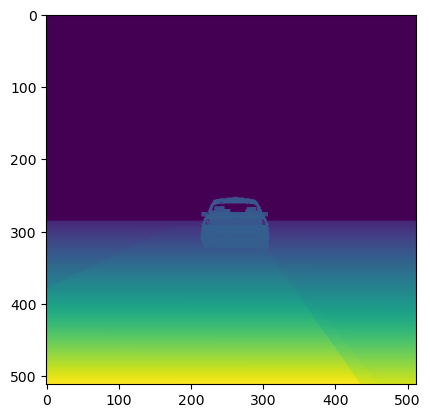

In [21]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Replace "0" with the index of the GPU you want to use


import time
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

def calculate_error(data, predicted_result):
    tau = 0.1
    D_gt_tensor = torch.tensor(data, dtype=torch.float32)
    D_est_tensor = torch.tensor(predicted_result, dtype=torch.float32)
    E = torch.abs(D_gt_tensor - D_est_tensor)

    mask = (D_gt_tensor >= 0) & (E > tau)
    n_err = torch.sum(mask).item()
    #print('n_err:', n_err)

    mask_total = D_gt_tensor >= 0
    n_total = torch.sum(mask_total).item()
    #print('n_total:', n_total)

    d_err = n_err / n_total
    return d_err

first_data = 200  # Specify the number of the first data point
last_data = 325  # Specify the number of the last data point

errors = []
inference_times = []
for i in range(first_data, last_data + 1):
    L_tensor = torch.tensor(imagesL[i], dtype=torch.float32).cuda()
    R_tensor = torch.tensor(imagesR[i], dtype=torch.float32).cuda()

    L_tensor = L_tensor.unsqueeze(1)
    R_tensor = R_tensor.unsqueeze(1)

    # Start measuring time
    start_time = time.time()

    predicted_result_tensor = model(L_tensor, R_tensor)

    # End measuring time
    end_time = time.time()
    inference_time = end_time - start_time
    inference_times.append(inference_time)
    #print("Inference Time:", inference_time, "seconds")

    predicted_result = predicted_result_tensor.cpu().squeeze().detach().numpy()

    min_val = np.min(predicted_result)
    max_val = np.max(predicted_result)
    predicted_result = (predicted_result - min_val) / (max_val - min_val)

    error = calculate_error(data[i], predicted_result)
    errors.append(error)
    #print("error=", error)

average_error = sum(errors) / len(errors)
average_inference_time = sum(inference_times) / len(inference_times)
print("Average error:", average_error)
print("Average inference time:", average_inference_time, "seconds")

# Visualize the sample and predicted result
#plt.imshow(concatenated_sample, cmap='viridis')
#plt.show()
plt.imshow(predicted_result, cmap='viridis')
plt.show()
plt.imshow(data[i], cmap='viridis')
plt.show()

Average error: 0.007984255645700758
Average inference time: 0.0018967094987925918 seconds


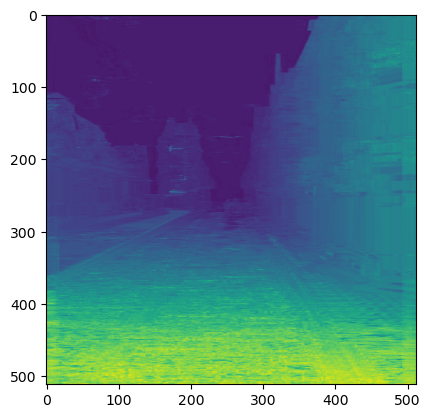

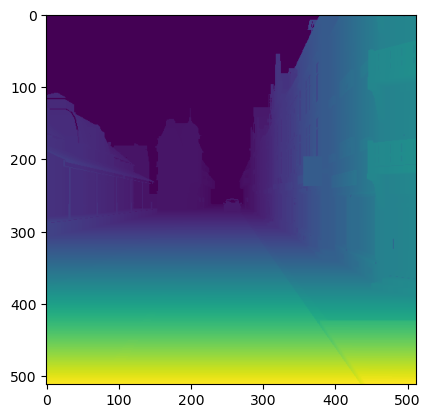

In [22]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # Replace "0" with the index of the GPU you want to use


import time
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

def calculate_error(data, predicted_result):
    D_gt_tensor = torch.tensor(data, dtype=torch.float32)
    D_est_tensor = torch.tensor(predicted_result, dtype=torch.float32)
    E = torch.square(D_gt_tensor - D_est_tensor)
    #print(E)
    E = torch.sum(E).item()
    
    mask_total = D_gt_tensor >= 0
    n_total = torch.sum(mask_total).item()
    #print('n_total:', n_total)

    d_err = E / n_total
    rms = torch.sqrt(torch.tensor(d_err))  # Convert d_err to a Tensor
    return d_err

first_data = 0  # Specify the number of the first data point
last_data = 100 # Specify the number of the last data point

errors = []
inference_times = []
for i in range(first_data, last_data + 1):
    L_tensor = torch.tensor(imagesL[i], dtype=torch.float32).cuda()
    R_tensor = torch.tensor(imagesR[i], dtype=torch.float32).cuda()

    L_tensor = L_tensor.unsqueeze(1)
    R_tensor = R_tensor.unsqueeze(1)

    # Start measuring time
    start_time = time.time()

    predicted_result_tensor = model(L_tensor, R_tensor)

    # End measuring time
    end_time = time.time()
    inference_time = end_time - start_time
    inference_times.append(inference_time)
    #print("Inference Time:", inference_time, "seconds")

    predicted_result = predicted_result_tensor.cpu().squeeze().detach().numpy()

    min_val = np.min(predicted_result)
    max_val = np.max(predicted_result)
    predicted_result = (predicted_result - min_val) / (max_val - min_val)

    error = calculate_error(data[i], predicted_result)
    errors.append(error)
    #print("error=", error)

average_error = sum(errors) / len(errors)
average_inference_time = sum(inference_times) / len(inference_times)
print("Average error:", average_error)
print("Average inference time:", average_inference_time, "seconds")

# Visualize the sample and predicted result
#plt.imshow(concatenated_sample, cmap='viridis')
#plt.show()
plt.imshow(predicted_result, cmap='viridis')
plt.show()
plt.imshow(data[i], cmap='viridis')
plt.show()

### 1.4. Training a quantized model

For compare between bw

In [8]:
import torch
import torch.nn as nn
from brevitas.nn import QuantConv1d, QuantReLU, QuantMaxPool1d, QuantUpsample,QuantIdentity

l1 = 64
l2 = 64
l3 = 64

input_size = s2
bw=4

# Define the model
class StereoModel(nn.Module):
    def __init__(self):
        super(StereoModel, self).__init__()

        self.path1_combined = nn.Sequential(
            QuantConv1d(1, l1, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.MaxPool1d(kernel_size=2),
            QuantConv1d(l1, l2, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.MaxPool1d(kernel_size=2),
            QuantConv1d(l2, l3, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False)
        )

        self.path2_combined = nn.Sequential(
            QuantConv1d(1, l1, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.MaxPool1d(kernel_size=2),
            QuantConv1d(l1, l2, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.MaxPool1d(kernel_size=2),
            QuantConv1d(l2, l3, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False)
        )

        # Combine paths
        self.combined = nn.Sequential(
            QuantConv1d(2 * l3, l3, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            QuantConv1d(l3, l2, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.Upsample(scale_factor=2),  # Upsample to match input size
            QuantConv1d(l2, l1, kernel_size=3, padding=1, weight_bit_width=bw),
            QuantReLU(weight_bit_width=bw ,return_quant_tensor=False),
            nn.Upsample(scale_factor=2)  # Upsample to match input size
        )

        self.output = nn.Conv1d(l1, 1, kernel_size=3, padding=1)

    def forward(self, left_input, right_input):
        path1_combined_out = self.path1_combined(left_input)
        path2_combined_out = self.path2_combined(right_input)

        combined = torch.cat((path1_combined_out, path2_combined_out), dim=1)
        combined_out = self.combined(combined)
        output = self.output(combined_out)

        return output


cuda
Epoch 1/10 - Train Loss: 0.0425 - Val Loss: 0.0260
Epoch 2/10 - Train Loss: 0.0255 - Val Loss: 0.0241
Epoch 3/10 - Train Loss: 0.0215 - Val Loss: 0.0248
Epoch 4/10 - Train Loss: 0.0205 - Val Loss: 0.0189
Epoch 5/10 - Train Loss: 0.0196 - Val Loss: 0.0184
Epoch 6/10 - Train Loss: 0.0208 - Val Loss: 0.0192
Epoch 7/10 - Train Loss: 0.0187 - Val Loss: 0.0163
Epoch 8/10 - Train Loss: 0.0168 - Val Loss: 0.0206
Epoch 9/10 - Train Loss: 0.0163 - Val Loss: 0.0155
Epoch 10/10 - Train Loss: 0.0145 - Val Loss: 0.0173
cuda
Epoch 1/10 - Train Loss: 0.0443 - Val Loss: 0.0331
Epoch 2/10 - Train Loss: 0.0302 - Val Loss: 0.0313
Epoch 3/10 - Train Loss: 0.0228 - Val Loss: 0.0180
Epoch 4/10 - Train Loss: 0.0190 - Val Loss: 0.0231
Epoch 5/10 - Train Loss: 0.0204 - Val Loss: 0.0176
Epoch 6/10 - Train Loss: 0.0184 - Val Loss: 0.0147
Epoch 7/10 - Train Loss: 0.0154 - Val Loss: 0.0125
Epoch 8/10 - Train Loss: 0.0161 - Val Loss: 0.0172
Epoch 9/10 - Train Loss: 0.0135 - Val Loss: 0.0120
Epoch 10/10 - Train 

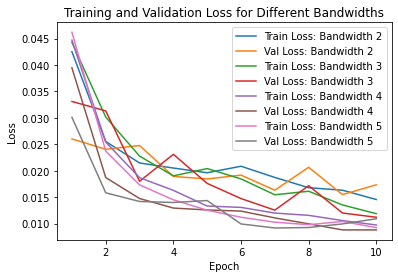

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Define different bandwidth values
bandwidths = [2, 3, 4, 5]

# Lists to store training and validation loss values for different bandwidths
train_loss_history = []
val_loss_history = []

for bw in bandwidths:
    # Define the model with the current bandwidth
    bw=bw
    model = StereoModel()

    # Define the loss function
    criterion = nn.MSELoss()

    # Define the optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adjust the learning rate as needed

    # Training loop
    epochs = 10  # Number of training epochs
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use CUDA if available

    model.to(device)  # Move the model to the device (GPU or CPU)
    print(device)

    train_loss_history_per_bw = []  # List to store the training loss for the current bandwidth
    val_loss_history_per_bw = []  # List to store the validation loss for the current bandwidth

    for epoch in range(epochs):
        train_loss = 0.0

        # Training
        model.train()  # Set the model to training mode
        for left, right, disparity in train_dataloader:

            # Move the tensors to the device
            left = left.to(device)
            right = right.to(device)
            disparity = disparity.to(device)


            # Zero the gradients
            optimizer.zero_grad()

            # Forward pass
            output = model(left, right)

            # Compute the loss
            loss = criterion(output, disparity)

            # Backward pass
            loss.backward()

            # Update the weights
            optimizer.step()

            # Accumulate the training loss
            train_loss += loss.item() * left.size(0)

        # Calculate the average training loss for the epoch
        train_loss /= len(train_dataloader.dataset)
        train_loss_history_per_bw.append(train_loss)

        # Validation
        model.eval()  # Set the model to evaluation mode
        val_loss = 0.0

        with torch.no_grad():
            for left, right, disparity in val_dataloader:

                # Move the tensors to the device
                left = left.to(device)
                right = right.to(device)
                disparity = disparity.to(device)

                # Forward pass
                output = model(left, right)

                # Compute the loss
                loss = criterion(output, disparity)

                # Accumulate the validation loss
                val_loss += loss.item() * left.size(0)

        # Calculate the average validation loss for the epoch
        val_loss /= len(val_dataloader.dataset)
        val_loss_history_per_bw.append(val_loss)

        # Print the training and validation losses for each epoch
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    # Append the training and validation losses for the current bandwidth to the main lists
    train_loss_history.append(train_loss_history_per_bw)
    val_loss_history.append(val_loss_history_per_bw)

# Plot the training and validation losses for different bandwidths
for i, bw in enumerate(bandwidths):
    plt.plot(range(1, epochs + 1), train_loss_history[i], label=f'Train Loss: Bandwidth {bw}')
    plt.plot(range(1, epochs + 1), val_loss_history[i], label=f'Val Loss: Bandwidth {bw}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Different Bandwidths')
plt.legend()
plt.show()


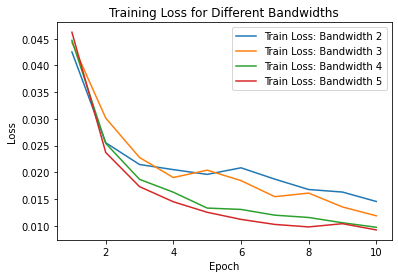

In [10]:
# Plot the training losses for different bandwidths
for i, bw in enumerate(bandwidths):
    plt.plot(range(1, epochs + 1), train_loss_history[i], label=f'Train Loss: Bandwidth {bw}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss for Different Bandwidths')
plt.legend()
#plt.show()

#plt.legend()
#plt.savefig('TrainingDiffBW.png', dpi=1000, format='png', bbox_inches='tight', pad_inches=0.2)



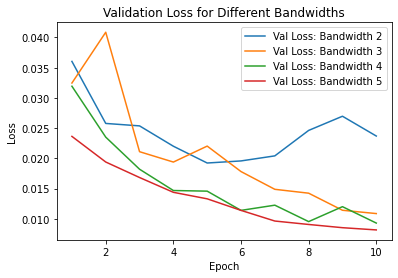

In [37]:
# Plot the validation losses for different bandwidths
for i, bw in enumerate(bandwidths):
    plt.plot(range(1, epochs + 1), val_loss_history[i], label=f'Val Loss: Bandwidth {bw}')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss for Different Bandwidths')
plt.legend()
#plt.show()

plt.legend()
plt.savefig('ValidatingDiffBW.png', dpi=1000, format='png', bbox_inches='tight', pad_inches=0.2)

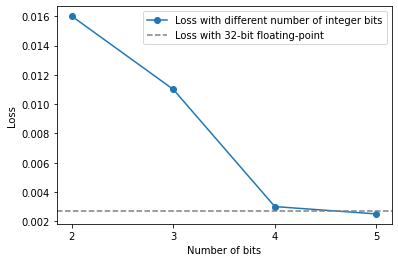

In [16]:
import matplotlib.pyplot as plt

# set the x and y values
x = [2, 3, 4, 5]
y = [0.016, 0.011, 0.003, 0.0025]

# create the plot with dots
plt.plot(x, y, '-o', label='Loss with different number of integer bits')

# set the x and y labels
plt.xlabel('Number of bits')
plt.ylabel('Loss')

# set the x-axis ticks
plt.xticks([2, 3, 4, 5])

# add a horizontal dotted line at y=0.0027
plt.axhline(y=0.0027, linestyle='--', color='gray', label='Loss with 32-bit floating-point')

# add a legend for the dotted line
plt.legend()

# show the plot
#plt.show()

#plt.legend()
plt.savefig('NumberOfBitsdot.png', dpi=2000, format='png', bbox_inches='tight', pad_inches=0.2)

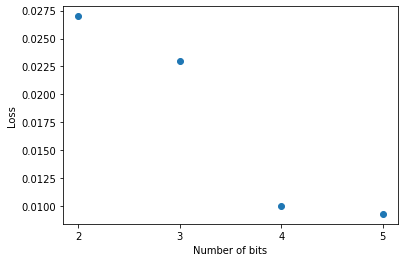

In [24]:

import matplotlib.pyplot as plt

# set the x and y values
x = [2, 3, 4, 5]
y = [0.027, 0.023, 0.01, 0.0093]

# create the plot with dots
plt.plot(x, y, 'o')

# set the x and y labels
plt.xlabel('Number of bits')
plt.ylabel('Loss')

# set the x-axis ticks
plt.xticks([2, 3, 4,5])

# show the plot
#plt.show()

#plt.legend()
plt.savefig('NumberOfBits.png', dpi=2000, format='png', bbox_inches='tight', pad_inches=0.2)


In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

bw=4
# Define the model
model = StereoModel()

# Define the loss function
criterion = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adjust the learning rate as needed

# Training loop
epochs = 30 # Number of training epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use CUDA if available

model.to(device)  # Move the model to the device (GPU or CPU)

# Lists to store training and validation loss values
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = 0.0

    # Training
    model.train()  # Set the model to training mode
    for left, right, disparity in train_dataloader:

        # Move the tensors to the device
        left = left.to(device)
        right = right.to(device)
        disparity = disparity.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(left, right)

        # Compute the loss
        loss = criterion(output, disparity)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # Accumulate the training loss
        train_loss += loss.item() * left.size(0)

    # Calculate the average training loss for the epoch
    train_loss /= len(train_dataloader.dataset)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0

    with torch.no_grad():
        for left, right, disparity in val_dataloader:

            # Move the tensors to the device
            left = left.to(device)
            right = right.to(device)
            disparity = disparity.to(device)

            # Forward pass
            output = model(left, right)

            # Compute the loss
            loss = criterion(output, disparity)

            # Accumulate the validation loss
            val_loss += loss.item() * left.size(0)

    # Calculate the average validation loss for the epoch
    val_loss /= len(val_dataloader.dataset)
    val_loss_history.append(val_loss)

    # Print the losses for each epoch
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


Epoch 1/30 - Train Loss: 0.0479 - Val Loss: 0.0318
Epoch 2/30 - Train Loss: 0.0259 - Val Loss: 0.0188
Epoch 3/30 - Train Loss: 0.0196 - Val Loss: 0.0200
Epoch 4/30 - Train Loss: 0.0181 - Val Loss: 0.0150
Epoch 5/30 - Train Loss: 0.0154 - Val Loss: 0.0172
Epoch 6/30 - Train Loss: 0.0145 - Val Loss: 0.0124
Epoch 7/30 - Train Loss: 0.0131 - Val Loss: 0.0140
Epoch 8/30 - Train Loss: 0.0127 - Val Loss: 0.0123
Epoch 9/30 - Train Loss: 0.0113 - Val Loss: 0.0108
Epoch 10/30 - Train Loss: 0.0101 - Val Loss: 0.0092
Epoch 11/30 - Train Loss: 0.0093 - Val Loss: 0.0096
Epoch 12/30 - Train Loss: 0.0090 - Val Loss: 0.0083
Epoch 13/30 - Train Loss: 0.0084 - Val Loss: 0.0082
Epoch 14/30 - Train Loss: 0.0086 - Val Loss: 0.0095
Epoch 15/30 - Train Loss: 0.0083 - Val Loss: 0.0077
Epoch 16/30 - Train Loss: 0.0081 - Val Loss: 0.0090
Epoch 17/30 - Train Loss: 0.0082 - Val Loss: 0.0074
Epoch 18/30 - Train Loss: 0.0080 - Val Loss: 0.0102
Epoch 19/30 - Train Loss: 0.0077 - Val Loss: 0.0069
Epoch 20/30 - Train L

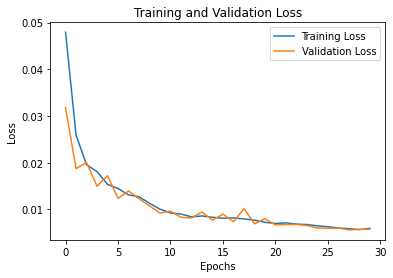

In [41]:
import matplotlib.pyplot as plt

epochs = range(0, len(train_loss_history) )
plt.plot(epochs, train_loss_history, label='Training Loss')
plt.plot(epochs, val_loss_history, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
#plt.show()

plt.legend()
plt.savefig('afterQ.png', dpi=1000, format='png', bbox_inches='tight', pad_inches=0.2)

Average error: 0.26144817897251676
Average inference time: 0.027389791276719835 seconds


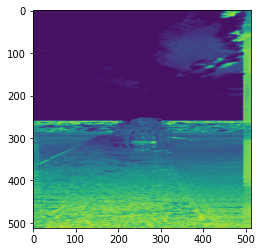

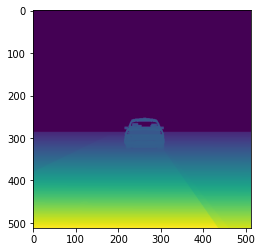

In [48]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Replace "0" with the index of the GPU you want to use


import time
import matplotlib.pyplot as plt
import torch
import numpy as np

model.eval()

def calculate_error(data, predicted_result):
    tau = 0.1
    D_gt_tensor = torch.tensor(data, dtype=torch.float32)
    D_est_tensor = torch.tensor(predicted_result, dtype=torch.float32)
    E = torch.abs(D_gt_tensor - D_est_tensor)

    mask = (D_gt_tensor >= 0) & (E > tau)
    n_err = torch.sum(mask).item()
    #print('n_err:', n_err)

    mask_total = D_gt_tensor >= 0
    n_total = torch.sum(mask_total).item()
    #print('n_total:', n_total)

    d_err = n_err / n_total
    return d_err

first_data = 200 # Specify the number of the first data point
last_data = 325  # Specify the number of the last data point

errors = []
inference_times = []
for i in range(first_data, last_data + 1):
    L_tensor = torch.tensor(imagesL[i], dtype=torch.float32).cuda()
    R_tensor = torch.tensor(imagesR[i], dtype=torch.float32).cuda()

    L_tensor = L_tensor.unsqueeze(1)
    R_tensor = R_tensor.unsqueeze(1)

    # Start measuring time
    start_time = time.time()

    predicted_result_tensor = model(L_tensor, R_tensor)

    # End measuring time
    end_time = time.time()
    inference_time = end_time - start_time
    inference_times.append(inference_time)
    #print("Inference Time:", inference_time, "seconds")

    predicted_result = predicted_result_tensor.cpu().squeeze().detach().numpy()

    min_val = np.min(predicted_result)
    max_val = np.max(predicted_result)
    predicted_result = (predicted_result - min_val) / (max_val - min_val)

    error = calculate_error(data[i], predicted_result)
    errors.append(error)
    #print("error=", error)

average_error = sum(errors) / len(errors)
average_inference_time = sum(inference_times) / len(inference_times)
print("Average error:", average_error)
print("Average inference time:", average_inference_time, "seconds")

# Visualize the sample and predicted result
plt.imshow(predicted_result, cmap='viridis')
plt.show()
plt.imshow(data[i], cmap='viridis')
plt.show()

Train with Brevitas

In [21]:
import torch
import torch.nn as nn
#from torchsummary import summary
import brevitas.nn as qnn

l1 = 64
l2 = 64
l3 = 64

input_size = s2
bw=4

# Define the model
class StereoModel(nn.Module):
    def __init__(self):
        super(StereoModel, self).__init__()

        self.model = nn.Sequential(
            qnn.QuantIdentity(bit_width=bw),
            qnn.QuantConv2d(1, l1, kernel_size=(3, 1),bias=True, padding=(1, 0), weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=True),
            qnn.QuantConv2d(l1, l2, kernel_size=(3, 1),bias=True, padding=(1, 0), weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=True),
            qnn.QuantConv2d(l2, l3, kernel_size=(3, 1),bias=True, padding=(1, 0), weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=True),
            qnn.QuantConv2d(l3, 1, kernel_size=(3, 1),bias=True, padding=(1, 0), weight_bit_width=bw)
        )

    def forward(self, left_input):
        output = self.model(left_input)
        return output

# Create an instance of the model
model = StereoModel()

# Move the model to the desired device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Print the model summary
print(model)
#summary(model, input_size=(1, 1, input_size))  # Note the change in input size


StereoModel(
  (model): Sequential(
    (0): QuantIdentity(
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (act_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (fused_activation_quant_proxy): FusedActivationQuantProxy(
          (activation_impl): Identity()
          (tensor_quant): RescalingIntQuant(
            (int_quant): IntQuant(
              (float_to_int_impl): RoundSte()
              (tensor_clamp_impl): TensorClamp()
              (delay_wrapper): DelayWrapper(
                (delay_impl): _NoDelay()
              )
            )
            (scaling_impl): ParameterFromRuntimeStatsScaling(
              (stats_input_view_shape_impl): OverTensorView()
              (stats): _Stats(
                (stats_impl): AbsPercentile()
              )
              (restrict_clamp_scaling): _RestrictClampValue(
                (clamp_min_ste): Identity()
                (restric

In [10]:
#from torchsummary import summary
import torch
import torch.nn as nn
import brevitas.nn as qnn

l1 = 64
l2 = 128
l3 = 256

input_size = s2
bw=8

# Define the model
class StereoModel(nn.Module):
    def __init__(self):
        super(StereoModel, self).__init__()

        self.model = nn.Sequential(
            qnn.QuantConv1d(1, l1, kernel_size=3, padding=1, weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=False),
            qnn.QuantConv1d(l1, l2, kernel_size=3, padding=1, weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=False),
            qnn.QuantConv1d(l2, l3, kernel_size=3, padding=1, weight_bit_width=bw),
            qnn.QuantReLU(weight_bit_width=bw, return_quant_tensor=False),
            qnn.QuantConv1d(l3, 1, kernel_size=3, padding=1, weight_bit_width=bw)
        )

    def forward(self, left_input):
        output = self.model(left_input)
        return output

# Create an instance of the model
model = StereoModel()

# Move the model to the desired device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# Print the model summary
print(model)
#summary(model, input_size=(1,1, input_size))

StereoModel(
  (model): Sequential(
    (0): QuantConv1d(
      1, 64, kernel_size=(3,), stride=(1,), padding=(1,)
      (input_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (output_quant): ActQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
      )
      (weight_quant): WeightQuantProxyFromInjector(
        (_zero_hw_sentinel): StatelessBuffer()
        (tensor_quant): RescalingIntQuant(
          (int_quant): IntQuant(
            (float_to_int_impl): RoundSte()
            (tensor_clamp_impl): TensorClampSte()
            (delay_wrapper): DelayWrapper(
              (delay_impl): _NoDelay()
            )
          )
          (scaling_impl): StatsFromParameterScaling(
            (parameter_list_stats): _ParameterListStats(
              (first_tracked_param): _ViewParameterWrapper(
                (view_shape_impl): OverTensorView()
              )
              (stats): _Stats(
                (stats_impl): Ab

In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

bw=4
# Define the model
model = StereoModel()

# Define the loss function
criterion = nn.MSELoss()

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)  # Adjust the learning rate as needed

# Training loop
epochs = 5 # Number of training epochs
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # Use CUDA if available

#model.to(device)  # Move the model to the device (GPU or CPU)

# Lists to store training and validation loss values
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    train_loss = 0.0

    # Training
    model.train()  # Set the model to training mode
    for left, right, disparity in train_dataloader:

        # Move the tensors to the device
        #left = left.to(device)
        #right = right.to(device)
        #disparity = disparity.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(left)

        # Compute the loss
        loss = criterion(output, disparity)

        # Backward pass
        loss.backward()

        # Update the weights
        optimizer.step()

        # Accumulate the training loss
        train_loss += loss.item() * left.size(0)

    # Calculate the average training loss for the epoch
    train_loss /= len(train_dataloader.dataset)
    train_loss_history.append(train_loss)

    # Validation
    model.eval()  # Set the model to evaluation mode
    val_loss = 0.0

    with torch.no_grad():
        for left, right, disparity in val_dataloader:

            # Move the tensors to the device
            #left = left.to(device)
            #right = right.to(device)
            #disparity = disparity.to(device)

            # Forward pass
            output = model(left)

            # Compute the loss
            loss = criterion(output, disparity)

            # Accumulate the validation loss
            val_loss += loss.item() * left.size(0)

    # Calculate the average validation loss for the epoch
    val_loss /= len(val_dataloader.dataset)
    val_loss_history.append(val_loss)

    # Print the losses for each epoch
    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")


RuntimeError: Expected 4-dimensional input for 4-dimensional weight [64, 1, 3, 1], but got 3-dimensional input of size [128, 1, 512] instead

Inference Time: 1.378629446029663 seconds
error= 0.9484910040626814


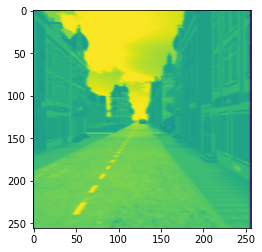

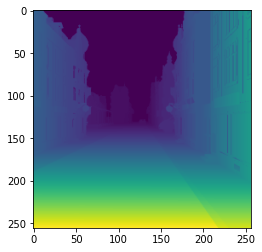

In [7]:
import time
import matplotlib.pyplot as plt
model.eval()

i = 0
L_tensor = torch.tensor(imagesL[i], dtype=torch.float32)
R_tensor = torch.tensor(imagesR[i], dtype=torch.float32)

L_tensor = L_tensor.unsqueeze(1)#.unsqueeze(1)
R_tensor = R_tensor.unsqueeze(1)#.unsqueeze(1)

# Start measuring time
start_time = time.time()

#predicted_result_tensor = model(L_tensor.to(device))
predicted_result_tensor = model(L_tensor)

# End measuring time
end_time = time.time()
inference_time = end_time - start_time
print("Inference Time:", inference_time, "seconds")

predicted_result = predicted_result_tensor.cpu().squeeze().detach().numpy()

import torch

def disp_error(D_gt, D_est):
    tau = [0.01171875, 0.05]
    D_gt_tensor = torch.tensor(D_gt, dtype=torch.float32)
    D_est_tensor = torch.tensor(D_est, dtype=torch.float32)
    E = torch.abs(D_gt_tensor - D_est_tensor)

    mask = (D_gt_tensor > 0) & (E > tau[0]) & (E / torch.abs(D_gt_tensor) > tau[1])
    n_err = torch.sum(mask).item()

    mask_total = D_gt_tensor > 0
    n_total = torch.sum(mask_total).item()

    d_err = n_err / n_total
    return d_err


error = disp_error(data[i], predicted_result)
print("error=", error)


# Visualize the sample and predicted result
#plt.imshow(concatenated_sample, cmap='viridis')
#plt.show()
plt.imshow(predicted_result, cmap='viridis')
plt.show()
plt.imshow(data[i], cmap='viridis')
plt.show()

In [10]:
R_tensor.size()

torch.Size([256, 1, 256])

In [11]:
#torch.save(model.state_dict(), 'savelocal8')

In [12]:
''''if os.path.exists('savelocal32'):
    model = MyModel(input_shape, output_shape)
    model.load_state_dict(torch.load('savelocal32'))
    model.eval()
    print("Pretrained model is loaded.")
else:
    model = train(model_path)''''

SyntaxError: EOL while scanning string literal (<ipython-input-12-8aab77f327a2>, line 7)

### 1.5. Visualizing predictions

## 2. Building with FINN

### 2.1. Brevitas export

In [41]:
from finn.util.visualization import showSrc, showInNetron
from finn.util.basic import make_build_dir
import onnx
from finn.util.test import get_test_model_trained
import brevitas.onnx as bo

build_dir = "/workspace/finn"

bo.export_finn_onnx(model , (1,1,s1) , build_dir+"/b64_w1_a1.onnx")


RuntimeError: Expected 4-dimensional input for 4-dimensional weight [64, 1, 3, 1], but got 3-dimensional input of size [1, 1, 256] instead

In [20]:
from finn.util.visualization import showSrc, showInNetron
from finn.util.basic import make_build_dir
from finn.core.modelwrapper import ModelWrapper

build_dir='.'   
model_onnx = build_dir + "/b64_w2_a1.onnx"
!rm -f {build_dir}/*onnx

import onnx
from finn.util.test import get_test_model_trained
import brevitas.onnx as bo


_ = bo.export_finn_onnx(model, (1, 1, s1,1), model_onnx)
model = ModelWrapper(model_onnx)

TypeError: empty(): argument 'size' must be tuple of ints, but found element of type tuple at pos 1

# 2. Network Preparation

### 2.1. Tidy-up transformations

In [43]:
from finn.transformation.general import GiveReadableTensorNames, GiveUniqueNodeNames, RemoveStaticGraphInputs
from finn.transformation.infer_shapes import InferShapes
from finn.transformation.infer_datatypes import InferDataTypes
from finn.transformation.fold_constants import FoldConstants

model = model.transform(InferShapes())
model = model.transform(FoldConstants())
model = model.transform(GiveUniqueNodeNames())
model = model.transform(GiveReadableTensorNames())
model = model.transform(InferDataTypes())
model = model.transform(RemoveStaticGraphInputs())

model.save(build_dir + "/b64_nn_tidy.onnx")
#showInNetron(build_dir+"/oftec_nn_tidy.onnx")

### 2.4. Streamlining

In [44]:
from finn.transformation.streamline import Streamline
from finn.transformation.streamline.reorder import MoveScalarLinearPastInvariants
import finn.transformation.streamline.absorb as absorb

model = ModelWrapper(build_dir+"/b64_nn_tidy.onnx")
# move initial Mul (from preproc) past the Reshape
model = model.transform(MoveScalarLinearPastInvariants())
# streamline
model = model.transform(Streamline())
model.save(build_dir+"/b64_nn_streamlined.onnx")
#showInNetron(build_dir+"/oftec_nn_streamlined.onnx")

### 2.3. Conversion to HLS layers

In [45]:
import finn.transformation.fpgadataflow.convert_to_hls_layers as to_hls

model = ModelWrapper(build_dir+"/b64_nn_streamlined.onnx")
model = model.transform(to_hls.InferBinaryStreamingFCLayer("decoupled"))

# TopK to LabelSelect
model = model.transform(to_hls.InferLabelSelectLayer())

# input quantization (if any) to standalone thresholding
model = model.transform(to_hls.InferThresholdingLayer())
model.save(build_dir+"/b64_nn_hls_layers.onnx")
#showInNetron(build_dir+"/oftec_nn_hls_layers.onnx")

### 3. Building the Network

### 3.1. Stitched IP, out-of-context synth and rtlsim Performance

In [15]:
import finn.builder.build_dataflow as build
import finn.builder.build_dataflow_config as build_cfg
import os
import shutil

model_file = build_dir+"/b64_w2_a1.onnx"

rtlsim_output_dir = "output_ipstitch_ooc_rtlsim"

#Delete previous run results if exist
if os.path.exists(rtlsim_output_dir):
    shutil.rmtree(rtlsim_output_dir)

cfg_stitched_ip = build.DataflowBuildConfig(
    output_dir          = rtlsim_output_dir,
    mvau_wwidth_max     = 80,
    target_fps          = 1000000,
    synth_clk_period_ns = 10.0,
    fpga_part           = "xc7a200t",#"xc7z020clg400-1",-1sbg484c
    generate_outputs=[
        build_cfg.DataflowOutputType.PYNQ_DRIVER,
        build_cfg.DataflowOutputType.STITCHED_IP,
        build_cfg.DataflowOutputType.RTLSIM_PERFORMANCE,
        build_cfg.DataflowOutputType.ESTIMATE_REPORTS,
        build_cfg.DataflowOutputType.OOC_SYNTH,
        build_cfg.DataflowOutputType.BITFILE,
        build_cfg.DataflowOutputType.DEPLOYMENT_PACKAGE,
    ],
)

In [16]:
%%time
build.build_dataflow_cfg(model_file, cfg_stitched_ip)

Building dataflow accelerator from ./b64_w2_a1.onnx
Intermediate outputs will be generated in /tmp/finn_dev_jokar
Final outputs will be generated in output_ipstitch_ooc_rtlsim
Build log is at output_ipstitch_ooc_rtlsim/build_dataflow.log
Running step: step_qonnx_to_finn [1/17]
Running step: step_tidy_up [2/17]
Running step: step_streamline [3/17]
Running step: step_convert_to_hls [4/17]
Running step: step_create_dataflow_partition [5/17]
Running step: step_target_fps_parallelization [6/17]
Running step: step_apply_folding_config [7/17]
Running step: step_generate_estimate_reports [8/17]
Running step: step_hls_codegen [9/17]
Running step: step_hls_ipgen [10/17]
Running step: step_set_fifo_depths [11/17]
Running step: step_create_stitched_ip [12/17]
Running step: step_measure_rtlsim_performance [13/17]
Running step: step_out_of_context_synthesis [14/17]
Running step: step_synthesize_bitfile [15/17]
Running step: step_make_pynq_driver [16/17]
Running step: step_deployment_package [17/17]


0

In [48]:
!cat /workspace/finn-base/src/finn/custom_op/general/im2col.py

import numpy as np

import finn.util.basic as util
from finn.core.datatype import DataType
from finn.custom_op.base import CustomOp

# adapted from A. Karpathy's CS231 im2col code
# utilities to generate a patch matrix from a multichannel image
# of shape (batches, channels, height, width)
# note: the spatial dimensions can be set to 1 to indicate
# a dummy dimension (e.g. 1D convs represented as 2D)


def compute_conv_output_dim(ifm_dim, k, stride, total_pad=0, dilation=1):
    """Returns spatial output dimension size for convolution with given params.
    total_pad gives the total amount of padding along the entire axis
    (both sides included).
    """
    if ifm_dim == 1:
        # indicates dummy dimension, keep as-is
        # Also ensure that every call to this function respects the expected
        # kernel shape and padding
        assert (
            k == 1 and total_pad == 0
        ), "Unexpected kernel shape and padding for 1D input image"
        out_dim = 1
    else:
 

### 3.2. Showing the results

In [ ]:
! ls {rtlsim_output_dir}/stitched_ip

In [ ]:
! ls {rtlsim_output_dir}/report

In [ ]:
! cat {rtlsim_output_dir}/report/ooc_synth_and_timing.json

In [ ]:
! cat {rtlsim_output_dir}/report/rtlsim_performance.json

In [ ]:
! cat {rtlsim_output_dir}/final_hw_config.json

In [ ]:
!ls output_ipstitch_ooc_rtlsim/stitched_ip

In [ ]:
!cat output_ipstitch_ooc_rtlsim/stitched_ip/all_verilog_srcs.txt